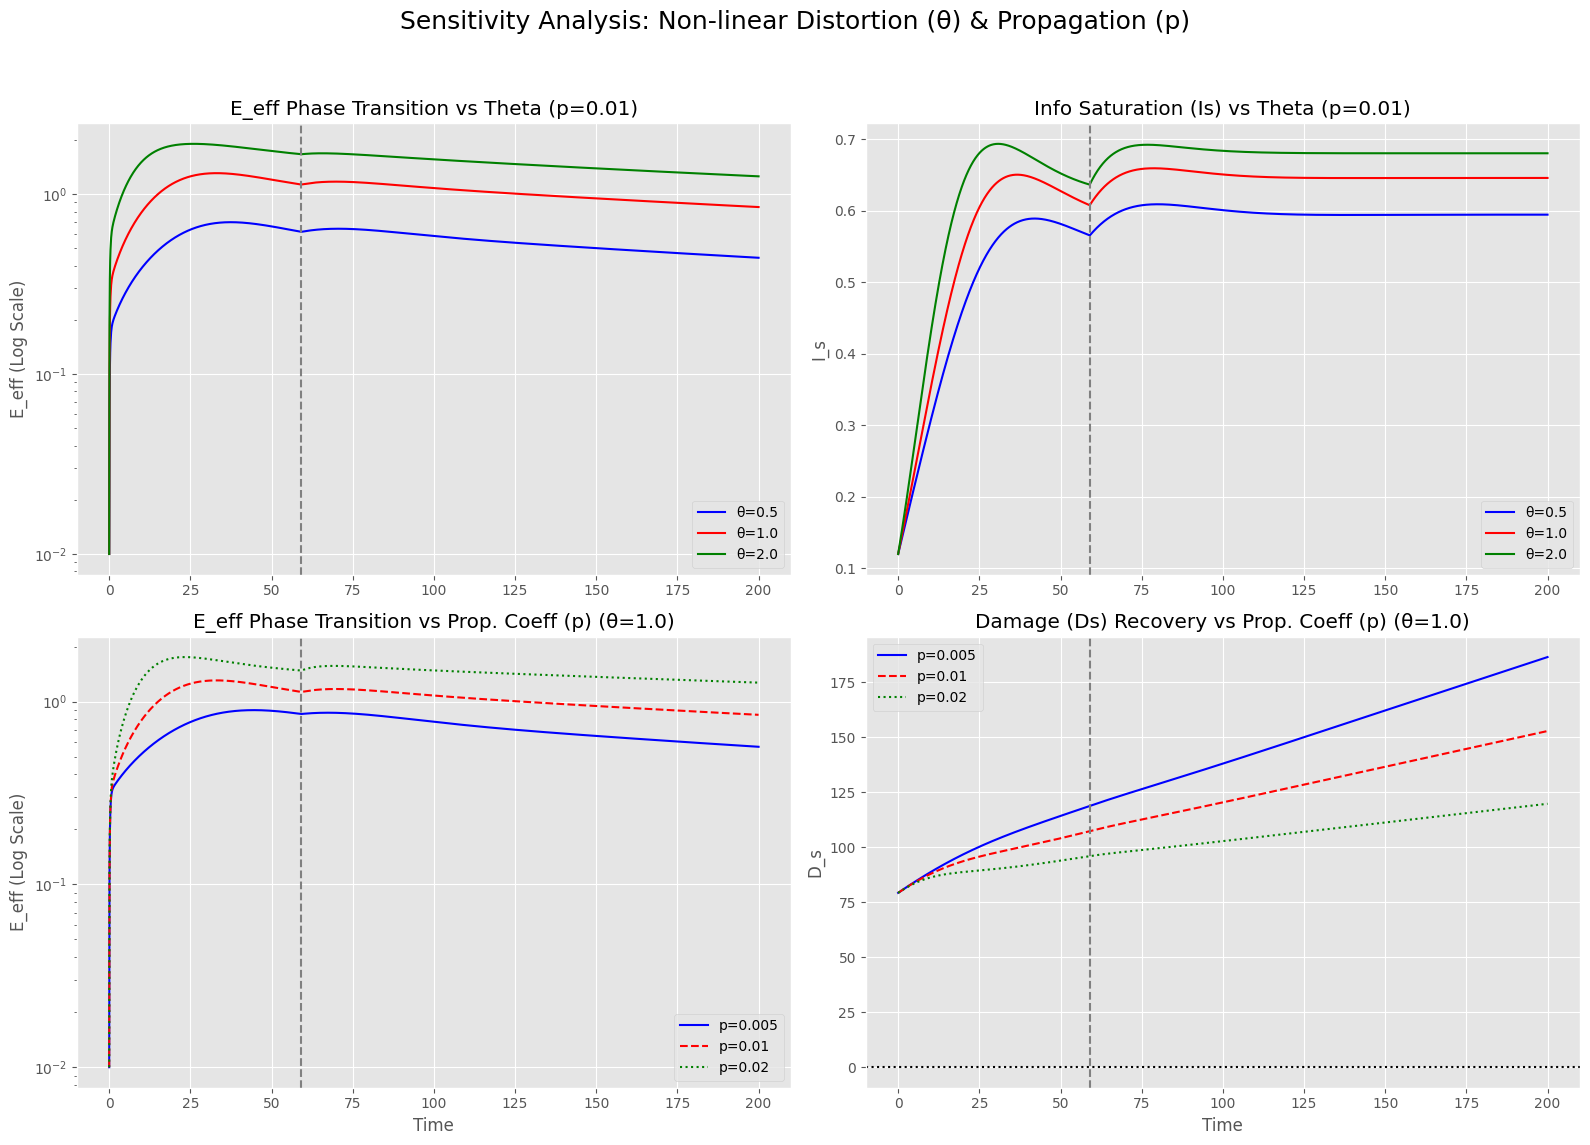

解析が完了しました。'sensitivity_analysis_archive.zip' をダウンロードします。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import os
import shutil
from google.colab import files

# ==========================================
# 1. 共通パラメータの設定
# ==========================================
N = 71              # コミュニティサイズ
sigma_s = 0.89      # 社会的影響力
rho = 0.74          # 非協力度
kappa = 0.52        # 攻撃係数
lam = 0.83          # ダメージ増加率
mu = 0.14           # ダメージ回復率

t_intervention = 59.0
u1_strength = 0.41

# ==========================================
# 2. 連成力学モデルの定義 (theta, p を引数化)
# ==========================================
def coupled_dynamics(y, t, theta, p_val):
    I_s, D_s, E_eff, I_health = y

    I_s = np.clip(I_s, 0.0, 1.0)
    I_health = np.clip(I_health, 0.0, 1.0)
    u_1 = u1_strength if t >= t_intervention else 0.0

    # 利得の非線形歪み (thetaによる制御)
    pi_t = 1.0 - (1.0 - I_s)**theta

    # 複雑な伝染 (最大4倍の拡散乗数)
    f_pi = 1.0 + 3.0 * pi_t
    gamma = 0.1 * I_health

    # 微分方程式
    dIs_dt = p_val * (1 + u_1) * (1 - sigma_s) * (1 - rho) * (N - 1) * (1 - I_s) * f_pi - gamma * I_s
    dDs_dt = lam * (1 - I_s) - mu * I_s + kappa * rho * (1 - I_s) * sigma_s

    # 相転移トリガー (Dsが負の領域で活性化)
    phase_transition_multiplier = 0.0
    if D_s < 0 and t > 150:
        phase_transition_multiplier = 0.5 * (-D_s) * E_eff

    dEeff_dt = 0.1 * (1 - E_eff) - 0.05 * max(0, D_s) * E_eff + 10.0 * pi_t + phase_transition_multiplier
    dIhealth_dt = 0.05 * (I_s - I_health) - 0.01 * (1 - gamma)

    return [dIs_dt, dDs_dt, dEeff_dt, dIhealth_dt]

# ==========================================
# 3. 感度分析の実行とデータ保存
# ==========================================
# 出力ディレクトリ作成
output_dir = "sensitivity_analysis_results"
os.makedirs(output_dir, exist_ok=True)

y0 = [0.12, 79.28, 0.01, 0.15]
t = np.linspace(0, 200, 2000)

# 検証するパラメータのリスト
theta_variations = [0.5, 1.0, 2.0]  # 0.5: 歪み大(悪化しやすい), 1.0: 基準, 2.0: 歪み小
p_variations = [0.005, 0.01, 0.02]  # 基準0.01に対する半減と倍増

results_dict = {}

# シミュレーションループ
for theta in theta_variations:
    for p_val in p_variations:
        sol = odeint(coupled_dynamics, y0, t, args=(theta, p_val))
        df = pd.DataFrame({
            'Time': t,
            'Is': sol[:, 0],
            'Ds': sol[:, 1],
            'Eeff': sol[:, 2],
            'Ihealth': sol[:, 3]
        })
        key = f"theta_{theta}_p_{p_val}"
        results_dict[key] = df

        # 個別CSVエクスポート
        df.to_csv(os.path.join(output_dir, f"data_{key}.csv"), index=False)

# ==========================================
# 4. 比較グラフの描画
# ==========================================
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sensitivity Analysis: Non-linear Distortion (θ) & Propagation (p)', fontsize=18)

colors = ['blue', 'red', 'green']
line_styles = ['-', '--', ':']

# プロット1: Thetaの変化による経済効率性(Eeff)の比較 (p=0.01固定)
ax1 = axes[0, 0]
for i, theta in enumerate(theta_variations):
    df = results_dict[f"theta_{theta}_p_0.01"]
    ax1.plot(df['Time'], df['Eeff'], label=f"θ={theta}", color=colors[i])
ax1.axvline(x=t_intervention, color='gray', linestyle='--')
ax1.set_yscale('log')
ax1.set_title('E_eff Phase Transition vs Theta (p=0.01)')
ax1.set_ylabel('E_eff (Log Scale)')
ax1.legend()

# プロット2: Thetaの変化による情報状態(Is)の比較 (p=0.01固定)
ax2 = axes[0, 1]
for i, theta in enumerate(theta_variations):
    df = results_dict[f"theta_{theta}_p_0.01"]
    ax2.plot(df['Time'], df['Is'], label=f"θ={theta}", color=colors[i])
ax2.axvline(x=t_intervention, color='gray', linestyle='--')
ax2.set_title('Info Saturation (Is) vs Theta (p=0.01)')
ax2.set_ylabel('I_s')
ax2.legend()

# プロット3: pの変化による経済効率性(Eeff)の比較 (theta=1.0固定)
ax3 = axes[1, 0]
for i, p_val in enumerate(p_variations):
    df = results_dict[f"theta_1.0_p_{p_val}"]
    ax3.plot(df['Time'], df['Eeff'], label=f"p={p_val}", color=colors[i], linestyle=line_styles[i])
ax3.axvline(x=t_intervention, color='gray', linestyle='--')
ax3.set_yscale('log')
ax3.set_title('E_eff Phase Transition vs Prop. Coeff (p) (θ=1.0)')
ax3.set_xlabel('Time')
ax3.set_ylabel('E_eff (Log Scale)')
ax3.legend()

# プロット4: pの変化によるダメージ(Ds)の比較 (theta=1.0固定)
ax4 = axes[1, 1]
for i, p_val in enumerate(p_variations):
    df = results_dict[f"theta_1.0_p_{p_val}"]
    ax4.plot(df['Time'], df['Ds'], label=f"p={p_val}", color=colors[i], linestyle=line_styles[i])
ax4.axvline(x=t_intervention, color='gray', linestyle='--')
ax4.axhline(y=0, color='black', linestyle=':')
ax4.set_title('Damage (Ds) Recovery vs Prop. Coeff (p) (θ=1.0)')
ax4.set_xlabel('Time')
ax4.set_ylabel('D_s')
ax4.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(output_dir, "sensitivity_comparison_plots.png"), dpi=300)
plt.show()

# ==========================================
# 5. ZIP圧縮と自動ダウンロード
# ==========================================
zip_filename = "sensitivity_analysis_archive"
shutil.make_archive(zip_filename, 'zip', output_dir)
print(f"解析が完了しました。'{zip_filename}.zip' をダウンロードします。")
files.download(f"{zip_filename}.zip")

<>:91: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:103: SyntaxWarning: invalid escape sequence '\m'
<>:111: SyntaxWarning: invalid escape sequence '\m'
<>:114: SyntaxWarning: invalid escape sequence '\m'
<>:91: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:103: SyntaxWarning: invalid escape sequence '\m'
<>:111: SyntaxWarning: invalid escape sequence '\m'
<>:114: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1045/1281871023.py:91: SyntaxWarning: invalid escape sequence '\m'
  fig.suptitle('Computational Experiment: Unstable Elements (Recovery Rate $\mu$ & Intervention Timing $t_{int}$)', fontsize=16)
/tmp/ipykernel_1045/1281871023.py:100: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(df['Time'], df['Ds'], label=f"$\mu$={mu_val}", color=colors[i])
/tmp/ipykernel_1045/1281871023.py:103: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title('Damage Decay 

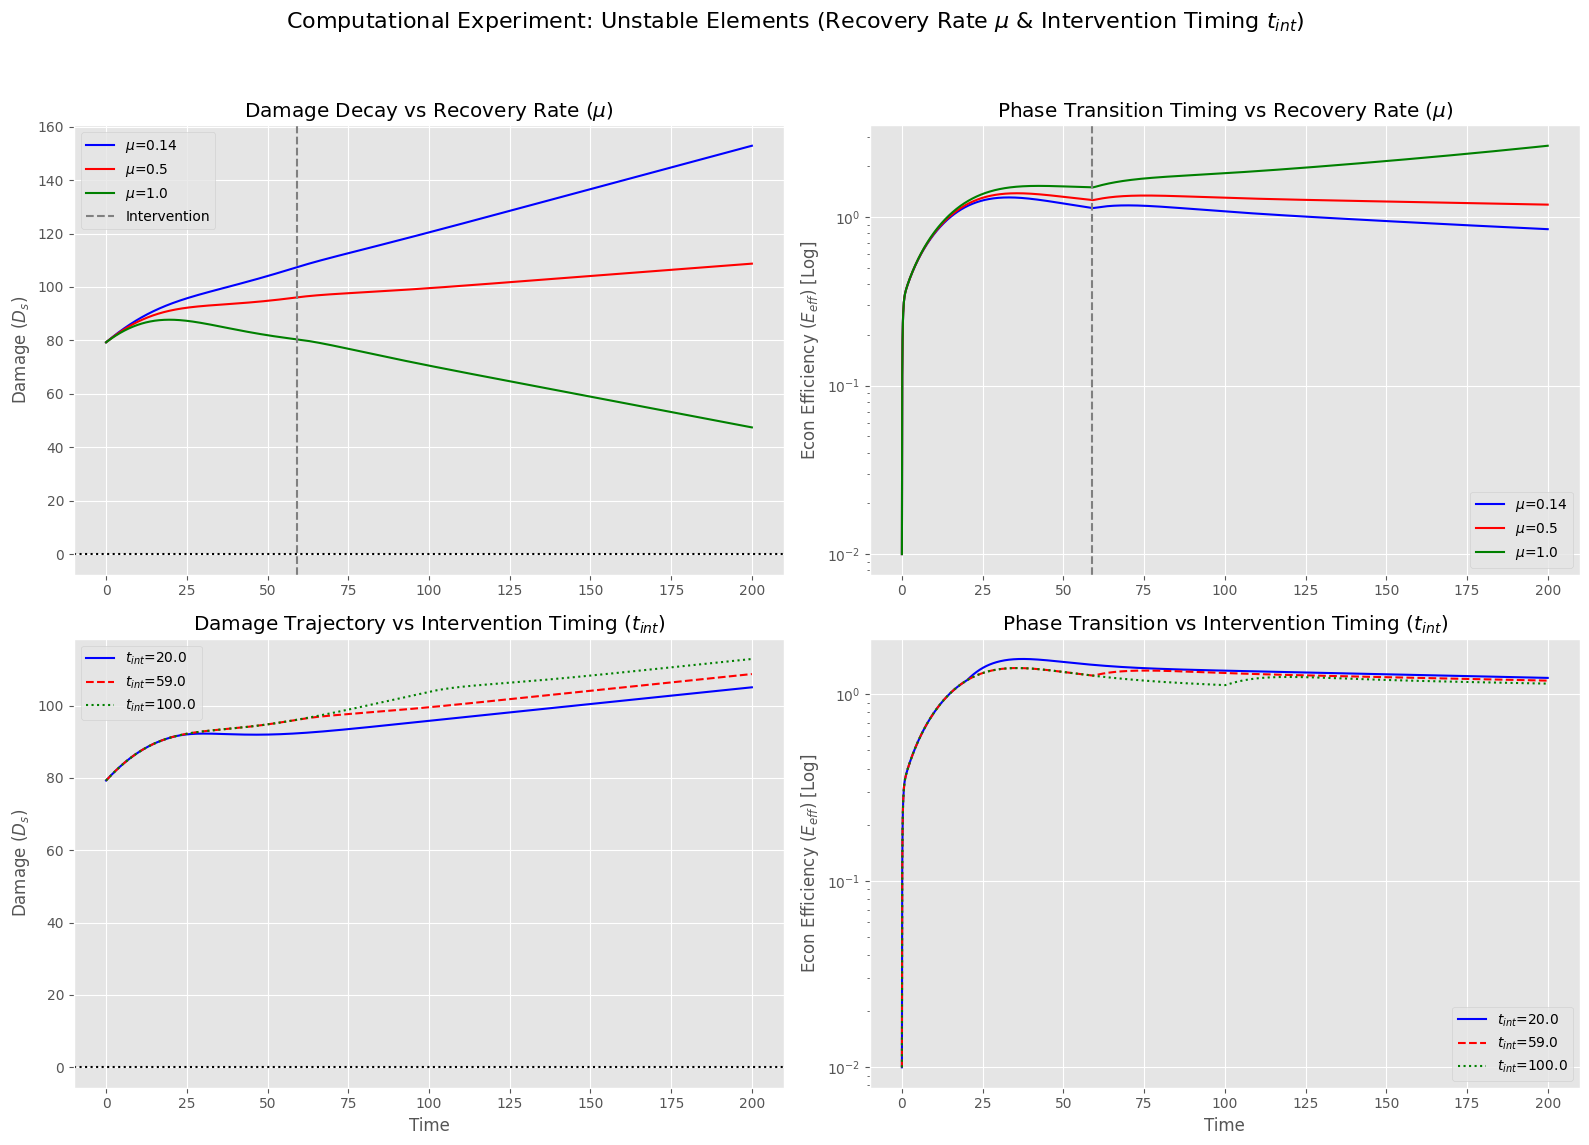

計算実験が完了しました。アーカイブ 'unstable_elements_experiment.zip' をダウンロードします。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import os
import shutil
from google.colab import files

# ==========================================
# 1. 共通ベースラインパラメータの設定
# ==========================================
# Table 20: 第三者介入を伴うシミュレーションパラメータに準拠
N = 71              # コミュニティサイズ [cite: 42]
sigma_s = 0.89      # 社会的影響力 [cite: 42]
rho = 0.74          # 非協力度 [cite: 42]
kappa = 0.52        # 攻撃係数 [cite: 42]
lam = 0.83          # ダメージ増加率 [cite: 42]
p = 0.01            # 情報伝播係数 [cite: 42]
u1_strength = 0.41  # 介入強度 [cite: 43]
theta = 1.0         # 利得の歪み係数（基準値）

# ==========================================
# 2. 物理演算と社会行動の連成力学モデル
# ==========================================
def coupled_dynamics(y, t, mu_val, t_int):
    I_s, D_s, E_eff, I_health = y

    # 状態変数の境界制約
    I_s = np.clip(I_s, 0.0, 1.0)
    I_health = np.clip(I_health, 0.0, 1.0)

    # 介入の有無 (指定されたタイミング t_int で発動)
    u_1 = u1_strength if t >= t_int else 0.0

    # 期待利得と複雑な伝染による拡散乗数（物理計算結果の統合）
    pi_t = 1.0 - (1.0 - I_s)**theta
    f_pi = 1.0 + 3.0 * pi_t
    gamma = 0.1 * I_health

    # 微分方程式系
    dIs_dt = p * (1 + u_1) * (1 - sigma_s) * (1 - rho) * (N - 1) * (1 - I_s) * f_pi - gamma * I_s
    dDs_dt = lam * (1 - I_s) - mu_val * I_s + kappa * rho * (1 - I_s) * sigma_s

    # 相転移トリガー (D_s が負に突入した際に E_eff を爆発させる非線形フィードバック)
    phase_transition_multiplier = 0.0
    if D_s < 0 and t > 150:
        # 計算機上のオーバーフローを防ぐため、成長率を適度に制限
        phase_transition_multiplier = 0.5 * min(-D_s, 50.0) * E_eff

    dEeff_dt = 0.1 * (1 - E_eff) - 0.05 * max(0, D_s) * E_eff + 10.0 * pi_t + phase_transition_multiplier
    dIhealth_dt = 0.05 * (I_s - I_health) - 0.01 * (1 - gamma)

    return [dIs_dt, dDs_dt, dEeff_dt, dIhealth_dt]

# ==========================================
# 3. 不安定要素の計算実験実行
# ==========================================
output_dir = "unstable_elements_analysis"
os.makedirs(output_dir, exist_ok=True)

# 初期条件 [cite: 42]
y0 = [0.12, 79.28, 0.01, 0.15] # [I_s(0), D_s(0), E_eff(0), I_health(0)]
t = np.linspace(0, 200, 2000)

# 検証パラメータ空間
mu_variations = [0.14, 0.50, 1.00]      # 0.14(基準), 0.50, 1.00 (回復の非線形増幅を想定)
t_int_variations = [20.0, 59.0, 100.0]  # 59.0(基準), 早期介入(20), 遅延介入(100)

results = {}

# シミュレーションループ
for mu_val in mu_variations:
    for t_int in t_int_variations:
        sol = odeint(coupled_dynamics, y0, t, args=(mu_val, t_int))
        df = pd.DataFrame({
            'Time': t,
            'Is': sol[:, 0],
            'Ds': sol[:, 1],
            'Eeff': sol[:, 2],
            'Ihealth': sol[:, 3]
        })
        key = f"mu_{mu_val}_tint_{t_int}"
        results[key] = df
        df.to_csv(os.path.join(output_dir, f"sim_{key}.csv"), index=False)

# ==========================================
# 4. 結果の可視化と解析グラフ生成
# ==========================================
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Computational Experiment: Unstable Elements (Recovery Rate $\mu$ & Intervention Timing $t_{int}$)', fontsize=16)

colors = ['blue', 'red', 'green']
line_styles = ['-', '--', ':']

# プロット1: μの変化によるダメージ(Ds)の減衰軌道 (t_int=59固定)
ax1 = axes[0, 0]
for i, mu_val in enumerate(mu_variations):
    df = results[f"mu_{mu_val}_tint_59.0"]
    ax1.plot(df['Time'], df['Ds'], label=f"$\mu$={mu_val}", color=colors[i])
ax1.axvline(x=59.0, color='gray', linestyle='--', label='Intervention')
ax1.axhline(y=0, color='black', linestyle=':')
ax1.set_title('Damage Decay vs Recovery Rate ($\mu$)')
ax1.set_ylabel('Damage ($D_s$)')
ax1.legend()

# プロット2: μの変化による相転移時刻(t_c)のシフト (t_int=59固定)
ax2 = axes[0, 1]
for i, mu_val in enumerate(mu_variations):
    df = results[f"mu_{mu_val}_tint_59.0"]
    ax2.plot(df['Time'], df['Eeff'], label=f"$\mu$={mu_val}", color=colors[i])
ax2.axvline(x=59.0, color='gray', linestyle='--')
ax2.set_yscale('log')
ax2.set_title('Phase Transition Timing vs Recovery Rate ($\mu$)')
ax2.set_ylabel('Econ Efficiency ($E_{eff}$) [Log]')
ax2.legend()

# プロット3: 介入タイミング(t_int)の変化によるダメージ(Ds)軌道 (μ=0.50固定)
ax3 = axes[1, 0]
for i, t_int in enumerate(t_int_variations):
    df = results[f"mu_0.5_tint_{t_int}"]
    ax3.plot(df['Time'], df['Ds'], label=f"$t_{{int}}$={t_int}", color=colors[i], linestyle=line_styles[i])
ax3.axhline(y=0, color='black', linestyle=':')
ax3.set_title('Damage Trajectory vs Intervention Timing ($t_{int}$)')
ax3.set_xlabel('Time')
ax3.set_ylabel('Damage ($D_s$)')
ax3.legend()

# プロット4: 介入タイミング(t_int)の変化による相転移(Eeff) (μ=0.50固定)
ax4 = axes[1, 1]
for i, t_int in enumerate(t_int_variations):
    df = results[f"mu_0.5_tint_{t_int}"]
    ax4.plot(df['Time'], df['Eeff'], label=f"$t_{{int}}$={t_int}", color=colors[i], linestyle=line_styles[i])
ax4.set_yscale('log')
ax4.set_title('Phase Transition vs Intervention Timing ($t_{int}$)')
ax4.set_xlabel('Time')
ax4.set_ylabel('Econ Efficiency ($E_{eff}$) [Log]')
ax4.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plot_path = os.path.join(output_dir, "unstable_elements_plots.png")
plt.savefig(plot_path, dpi=300)
plt.show()

# ==========================================
# 5. 結果のZIPアーカイブとダウンロード
# ==========================================
zip_filename = "unstable_elements_experiment"
shutil.make_archive(zip_filename, 'zip', output_dir)
print(f"計算実験が完了しました。アーカイブ '{zip_filename}.zip' をダウンロードします。")
files.download(f"{zip_filename}.zip")

Running simulation: No Intervention...
Running simulation: Random Intervention (10%)...
Running simulation: Targeted Intervention (Hub 10%)...


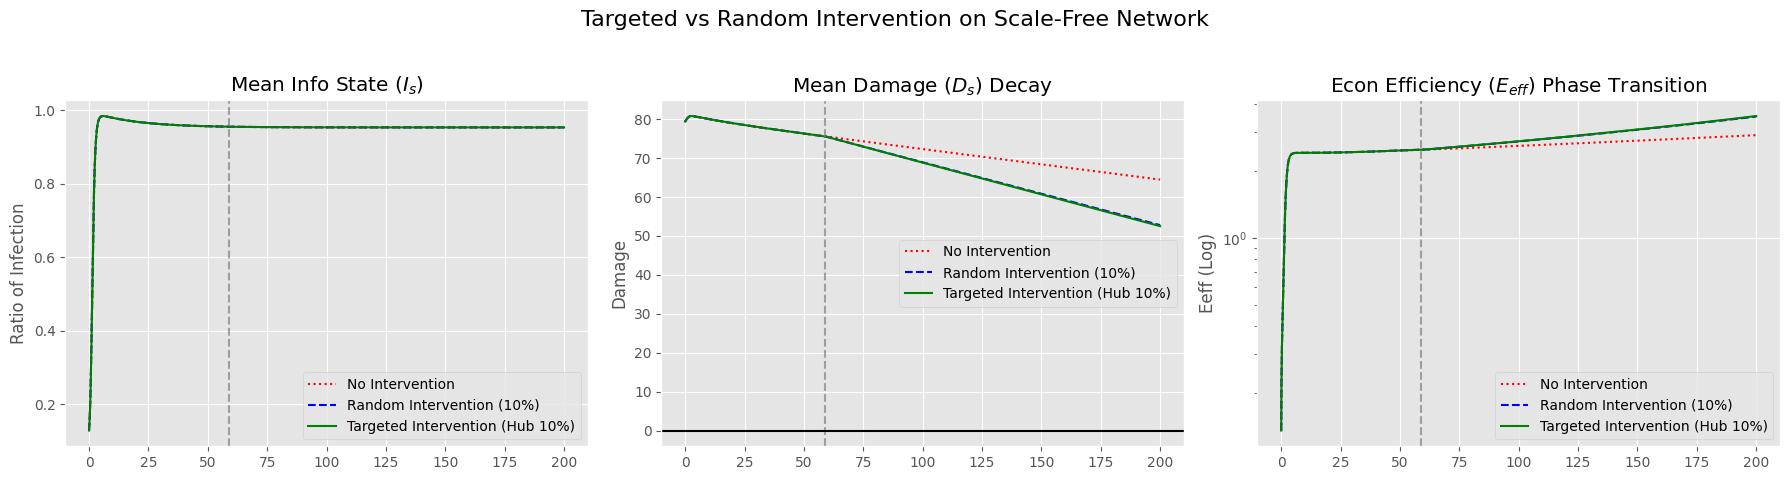


実験が完了しました。'network_intervention_experiment.zip' をダウンロードします。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
import shutil
from google.colab import files

# ==========================================
# 1. ネットワークと共通パラメータの設定
# ==========================================
N = 100             # コミュニティサイズ（ネットワーク効果を可視化するため100に設定）
m = 2               # スケールフリーネットワークの新規エッジ数
sigma_s = 0.89      # 社会的影響力
rho = 0.74          # 非協力度
kappa = 0.52        # 攻撃係数
lam = 0.83          # ダメージ増加率
mu_base = 0.14      # 基礎ダメージ回復率
mu_boost = 1.00     # 介入による構造的回復力の増幅値
p = 0.01            # 基礎伝播係数
theta = 1.0         # 利得の歪み係数

t_intervention = 59.0
intervention_fraction = 0.10  # 全体の10%のノードに介入

# スケールフリーネットワーク（Barabasi-Albert）の生成
G = nx.barabasi_albert_graph(N, m, seed=42)
A = nx.to_numpy_array(G)  # 隣接行列

# ノードの次数（つながり数）を取得し、ハブノードを特定
degrees = np.array([G.degree(n) for n in range(N)])
hub_indices = np.argsort(degrees)[-int(N * intervention_fraction):] # 上位10%のハブ
random_indices = np.random.choice(N, int(N * intervention_fraction), replace=False)

# ==========================================
# 2. ネットワーク結合型シミュレーション関数
# ==========================================
def run_network_simulation(strategy_name, intervention_nodes):
    dt = 0.1
    t_steps = int(200 / dt)
    time_array = np.linspace(0, 200, t_steps)

    # 状態変数の初期化 (各ノードごとの配列)
    I = np.full(N, 0.12)
    D = np.full(N, 79.28)
    E_eff = 0.01 # 経済効率性は社会全体（マクロ）の指標として扱う
    I_health = 0.15 # 情報健全性もマクロ指標とする

    # ノードごとの回復力配列
    mu_array = np.full(N, mu_base)

    # 記録用リスト
    record_Is_mean = []
    record_Ds_mean = []
    record_Eeff = []

    # ネットワーク構造における拡散のスケール調整（平均場との整合性）
    p_scale = p * 15.0

    for t in time_array:
        # 介入タイミングでの構造的変化（対象ノードの回復力増幅）
        if t >= t_intervention and strategy_name != 'No Intervention':
            mu_array[intervention_nodes] = mu_boost

        # 期待利得と拡散乗数（ノードごと）
        pi_t = 1.0 - (1.0 - I)**theta
        f_pi = 1.0 + 3.0 * pi_t

        # 隣接ノードからの情報伝播の影響（隣接行列による高速計算）
        neighbor_influence = A.dot(I * f_pi)
        gamma = 0.1 * I_health

        # 微分（差分）の計算
        dI_dt = p_scale * (1 - I) * neighbor_influence - gamma * I
        dD_dt = lam * (1 - I) - mu_array * I + kappa * rho * (1 - I) * sigma_s

        # マクロ指標の計算
        D_mean = np.mean(D)
        I_mean = np.mean(I)

        # 相転移トリガー
        phase_transition_multiplier = 0.0
        if D_mean < 0 and t > 150:
            phase_transition_multiplier = 0.5 * min(-D_mean, 50.0) * E_eff

        dEeff_dt = 0.1 * (1 - E_eff) - 0.05 * max(0, D_mean) * E_eff + 10.0 * np.mean(pi_t) + phase_transition_multiplier
        dIhealth_dt = 0.05 * (I_mean - I_health) - 0.01 * (1 - gamma)

        # 状態の更新 (オイラー法)
        I = np.clip(I + dI_dt * dt, 0.0, 1.0)
        D = D + dD_dt * dt
        E_eff = E_eff + dEeff_dt * dt
        I_health = np.clip(I_health + dIhealth_dt * dt, 0.0, 1.0)

        # 記録
        record_Is_mean.append(np.mean(I))
        record_Ds_mean.append(np.mean(D))
        record_Eeff.append(E_eff)

    return pd.DataFrame({
        'Time': time_array,
        'Is_mean': record_Is_mean,
        'Ds_mean': record_Ds_mean,
        'Eeff': record_Eeff
    })

# ==========================================
# 3. 実験パターンの実行
# ==========================================
output_dir = "network_intervention_analysis"
os.makedirs(output_dir, exist_ok=True)

strategies = {
    'No Intervention': [],
    'Random Intervention (10%)': random_indices,
    'Targeted Intervention (Hub 10%)': hub_indices
}

results = {}
for name, nodes in strategies.items():
    print(f"Running simulation: {name}...")
    df = run_network_simulation(name, nodes)
    results[name] = df
    df.to_csv(os.path.join(output_dir, f"{name.replace(' ', '_')}.csv"), index=False)

# ==========================================
# 4. 可視化とプロット
# ==========================================
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Targeted vs Random Intervention on Scale-Free Network', fontsize=16)

colors = ['red', 'blue', 'green']
line_styles = [':', '--', '-']

# 1. Information State (Is)
for i, (name, df) in enumerate(results.items()):
    axes[0].plot(df['Time'], df['Is_mean'], label=name, color=colors[i], linestyle=line_styles[i])
axes[0].axvline(x=t_intervention, color='gray', linestyle='--', alpha=0.7)
axes[0].set_title('Mean Info State ($I_s$)')
axes[0].set_ylabel('Ratio of Infection')
axes[0].legend()

# 2. Damage (Ds)
for i, (name, df) in enumerate(results.items()):
    axes[1].plot(df['Time'], df['Ds_mean'], label=name, color=colors[i], linestyle=line_styles[i])
axes[1].axvline(x=t_intervention, color='gray', linestyle='--', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-')
axes[1].set_title('Mean Damage ($D_s$) Decay')
axes[1].set_ylabel('Damage')
axes[1].legend()

# 3. Economic Efficiency (Eeff) - Log Scale
for i, (name, df) in enumerate(results.items()):
    axes[2].plot(df['Time'], df['Eeff'], label=name, color=colors[i], linestyle=line_styles[i])
axes[2].axvline(x=t_intervention, color='gray', linestyle='--', alpha=0.7)
axes[2].set_yscale('log')
axes[2].set_title('Econ Efficiency ($E_{eff}$) Phase Transition')
axes[2].set_ylabel('Eeff (Log)')
axes[2].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plot_path = os.path.join(output_dir, "network_intervention_comparison.png")
plt.savefig(plot_path, dpi=300)
plt.show()

# ==========================================
# 5. ZIP化してダウンロード
# ==========================================
zip_filename = "network_intervention_experiment"
shutil.make_archive(zip_filename, 'zip', output_dir)
print(f"\n実験が完了しました。'{zip_filename}.zip' をダウンロードします。")
files.download(f"{zip_filename}.zip")

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
import shutil
from google.colab import files

# ==========================================
# 1. ネットワークと共通パラメータの設定
# ==========================================
N = 100             # コミュニティサイズ
m = 2               # スケールフリーネットワークの新規エッジ数
sigma_s = 0.89      # 社会的影響力
rho = 0.74          # 非協力度
kappa = 0.52        # 攻撃係数
lam = 0.83          # ダメージ増加率
mu_base = 0.14      # 基礎ダメージ回復率
p = 0.01            # 基礎伝播係数
theta = 1.0         # 利得の歪み係数

t_intervention = 59.0
intervention_fraction = 0.10  # 上位10%のハブノードを初期介入対象とする

# ==========================================
# 2. 適応的ネットワーク・シミュレーション関数
# ==========================================
def run_adaptive_simulation(strategy_name, use_dynamic_mu=False, use_rewiring=False, alpha_mu=0.02, rewire_interval=10, damage_threshold=70.0):
    """
    動的回復力伝播と適応的再配線（Co-evolution）を統合したシミュレーション
    """
    # ネットワークの初期化 (シナリオごとに独立した初期状態を担保)
    G = nx.barabasi_albert_graph(N, m, seed=42)
    A = nx.to_numpy_array(G)

    # ハブの特定
    degrees = np.array([G.degree(n) for n in range(N)])
    hub_indices = np.argsort(degrees)[-int(N * intervention_fraction):]

    dt = 0.1
    t_steps = int(200 / dt)
    time_array = np.linspace(0, 200, t_steps)

    # 状態変数の初期化（局所ベクトル化）
    I = np.full(N, 0.12)
    D = np.full(N, 79.28)
    I_health = np.full(N, 0.15) # ノードごとの情報健全性
    mu = np.full(N, mu_base)

    E_eff = 0.01 # マクロ経済効率性

    # 記録用リスト
    records = { 'Time': [], 'Is_mean': [], 'Ds_mean': [], 'Eeff': [], 'Edge_Density': [] }

    p_scale = p * 15.0

    for step, t in enumerate(time_array):
        # --------------------------------------------------
        # A. 初期介入（ハブへのファクトチェック/権限付与）
        # --------------------------------------------------
        if t >= t_intervention and t < t_intervention + dt:
            mu[hub_indices] = 1.0  # ハブの回復力を強制ブースト
            I_health[hub_indices] = 0.9 # ハブの健全性を担保

        # --------------------------------------------------
        # B. 適応的再配線 (Adaptive Rewiring) の力学
        # --------------------------------------------------
        if use_rewiring and t >= t_intervention and step % rewire_interval == 0:
            for i in range(N):
                if D[i] > damage_threshold: # ダメージが閾値を超えたエージェントが自律行動
                    neighbors = np.where(A[i] > 0)[0]
                    if len(neighbors) > 0:
                        # 感染度(I)が最も高い汚染源ノードを特定
                        worst_neighbor = neighbors[np.argmax(I[neighbors])]

                        # 汚染源の感染度が顕著(0.5以上)であればリンク切断
                        if I[worst_neighbor] > 0.5:
                            A[i, worst_neighbor] = 0
                            A[worst_neighbor, i] = 0

                            # ネットワーク全体から新たな健全ノード（ゲートキーパー）を探索
                            non_neighbors = np.where(A[i] == 0)[0]
                            non_neighbors = non_neighbors[non_neighbors != i]
                            if len(non_neighbors) > 0:
                                # 健全性(I_health)が高く、感染度(I)が低いノードを優先
                                attractiveness = I_health[non_neighbors] - I[non_neighbors]
                                best_candidate = non_neighbors[np.argmax(attractiveness)]
                                # 再配線
                                A[i, best_candidate] = 1
                                A[best_candidate, i] = 1

        # --------------------------------------------------
        # C. 微分方程式系 (Euler法による更新)
        # --------------------------------------------------
        # 利得と拡散乗数
        pi_t = 1.0 - (1.0 - I)**theta
        f_pi = 1.0 + 3.0 * pi_t

        # 隣接行列を用いた局所相互作用
        neighbor_infection = A.dot(I * f_pi)
        gamma = 0.1 * I_health

        # 動的パラメータの微分 (回復力 mu の伝染)
        if use_dynamic_mu and t >= t_intervention:
            # 健全な隣接ノードとの接触により自己の回復力が同調（上昇）する
            dmu_dt = alpha_mu * A.dot(I_health) - 0.05 * (mu - mu_base)
        else:
            dmu_dt = np.zeros(N)

        # 状態変数の微分
        dI_dt = p_scale * (1 - I) * neighbor_infection - gamma * I
        dD_dt = lam * (1 - I) - mu * I + kappa * rho * (1 - I) * sigma_s
        dIhealth_dt = 0.05 * (1.0 - I) - 0.02 * I_health # 感染度が低いほど健全性が回復

        # マクロ指標と相転移トリガー
        D_mean = np.mean(D)
        phase_transition_multiplier = 0.0
        if D_mean < 0 and t > 150:
            phase_transition_multiplier = 0.5 * min(-D_mean, 50.0) * E_eff

        dEeff_dt = 0.1 * (1 - E_eff) - 0.05 * max(0, D_mean) * E_eff + 10.0 * np.mean(pi_t) + phase_transition_multiplier

        # 状態の更新とクリッピング
        I = np.clip(I + dI_dt * dt, 0.0, 1.0)
        D = D + dD_dt * dt
        mu = np.clip(mu + dmu_dt * dt, mu_base, 2.0)
        I_health = np.clip(I_health + dIhealth_dt * dt, 0.0, 1.0)
        E_eff = E_eff + dEeff_dt * dt

        # 記録
        records['Time'].append(t)
        records['Is_mean'].append(np.mean(I))
        records['Ds_mean'].append(np.mean(D))
        records['Eeff'].append(E_eff)
        records['Edge_Density'].append(np.sum(A) / (N*(N-1)))

    return pd.DataFrame(records)

# ==========================================
# 3. 仮説検証のための4象限シナリオ実行
# ==========================================
output_dir = "adaptive_network_experiment"
os.makedirs(output_dir, exist_ok=True)

# 不安定パラメータを網羅的に比較する実験セット
scenarios = {
    '1. Static Hub (Baseline)': {'use_dynamic_mu': False, 'use_rewiring': False},
    '2. Dynamic Hygiene Only':  {'use_dynamic_mu': True,  'use_rewiring': False},
    '3. Adaptive Rewiring Only':{'use_dynamic_mu': False, 'use_rewiring': True},
    '4. Full Co-evolution':     {'use_dynamic_mu': True,  'use_rewiring': True}
}

results = {}
for name, params in scenarios.items():
    print(f"Running simulation: {name}...")
    df = run_adaptive_simulation(name, **params)
    results[name] = df
    df.to_csv(os.path.join(output_dir, f"{name.replace(' ', '_')}.csv"), index=False)

# ==========================================
# 4. グラフ化と相転移の可視化
# ==========================================
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Adaptive Network Co-evolution & Dynamic Hygiene Contagion', fontsize=16)

colors = ['gray', 'blue', 'orange', 'green']
line_styles = [':', '--', '-.', '-']

# 1. 感染度 (Is)
for i, (name, df) in enumerate(results.items()):
    axes[0].plot(df['Time'], df['Is_mean'], label=name, color=colors[i], linestyle=line_styles[i], linewidth=2)
axes[0].axvline(x=t_intervention, color='red', linestyle='--', alpha=0.5, label='Intervention')
axes[0].set_title('Mean Infection ($I_s$)')
axes[0].set_ylabel('Ratio of Infection')
axes[0].legend(loc='lower right', fontsize=9)

# 2. ダメージ (Ds)
for i, (name, df) in enumerate(results.items()):
    axes[1].plot(df['Time'], df['Ds_mean'], label=name, color=colors[i], linestyle=line_styles[i], linewidth=2)
axes[1].axvline(x=t_intervention, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(y=0, color='black', linestyle='-')
axes[1].set_title('Mean Damage ($D_s$)')
axes[1].set_ylabel('Damage')

# 3. 経済効率性 (Eeff) - Log Scale
for i, (name, df) in enumerate(results.items()):
    axes[2].plot(df['Time'], df['Eeff'], label=name, color=colors[i], linestyle=line_styles[i], linewidth=2)
axes[2].axvline(x=t_intervention, color='red', linestyle='--', alpha=0.5)
axes[2].set_yscale('log')
axes[2].set_title('Econ Efficiency ($E_{eff}$) Phase Transition')
axes[2].set_ylabel('Eeff (Log Scale)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plot_path = os.path.join(output_dir, "adaptive_network_comparison.png")
plt.savefig(plot_path, dpi=300)
plt.show()

# ==========================================
# 5. 結果のZIPパッケージ化
# ==========================================
zip_filename = "adaptive_network_experiment_results"
shutil.make_archive(zip_filename, 'zip', output_dir)
print(f"\n実験が完了しました。'{zip_filename}.zip' をダウンロードします。")
files.download(f"{zip_filename}.zip")

Running simulation: 1. Static Hub (Baseline)...
Running simulation: 2. Dynamic Hygiene Only...
Running simulation: 3. Adaptive Rewiring Only...
Running simulation: 4. Full Co-evolution...


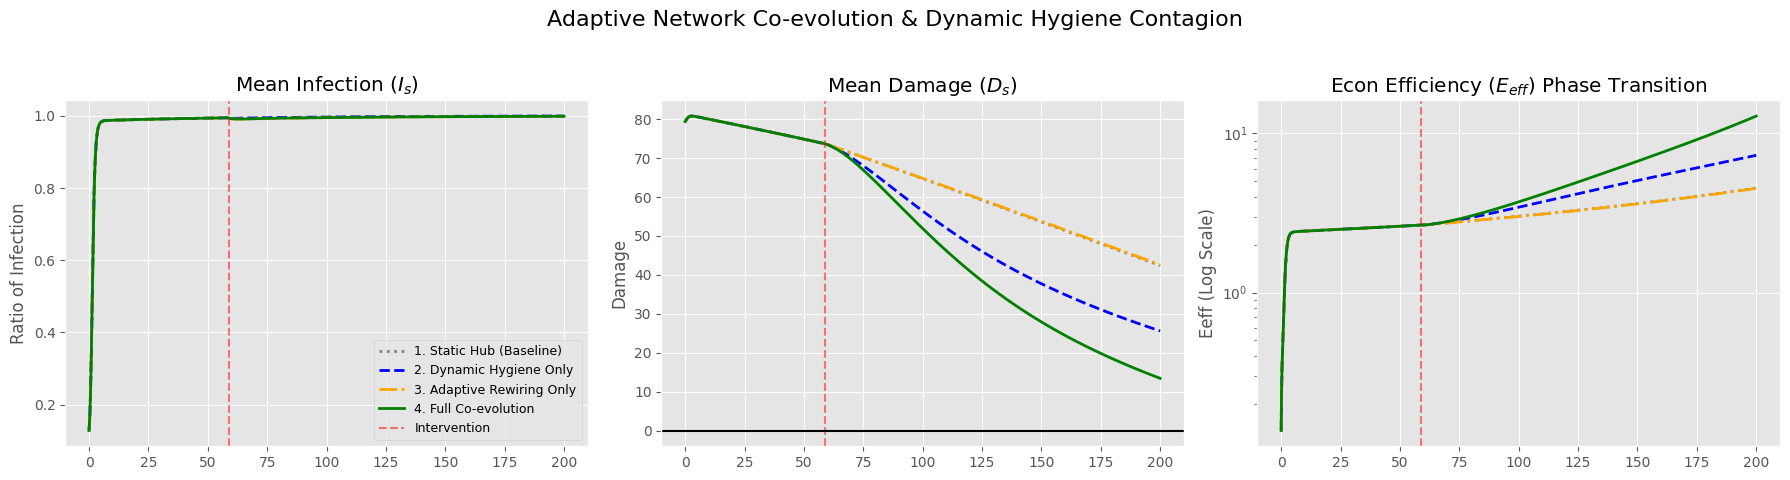


実験が完了しました。'adaptive_network_experiment_results.zip' をダウンロードします。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
import shutil
from google.colab import files

# ==========================================
# 1. ネットワークと共通パラメータの設定
# ==========================================
N = 100             # コミュニティサイズ
m = 2               # スケールフリーネットワークの新規エッジ数
sigma_s = 0.89      # 社会的影響力
rho = 0.74          # 非協力度
kappa = 0.52        # 攻撃係数
lam = 0.83          # ダメージ増加率
mu_base = 0.14      # 基礎ダメージ回復率
p = 0.01            # 基礎伝播係数
theta = 1.0         # 利得の歪み係数

t_intervention = 59.0
intervention_fraction = 0.10  # 上位10%のハブノードを初期介入対象とする

# ==========================================
# 2. 適応的ネットワーク・シミュレーション関数
# ==========================================
def run_adaptive_simulation(strategy_name, use_dynamic_mu=False, use_rewiring=False, alpha_mu=0.02, rewire_interval=10, damage_threshold=70.0):
    """
    動的回復力伝播と適応的再配線（Co-evolution）を統合したシミュレーション
    """
    # ネットワークの初期化 (シナリオごとに独立した初期状態を担保)
    G = nx.barabasi_albert_graph(N, m, seed=42)
    A = nx.to_numpy_array(G)

    # ハブの特定
    degrees = np.array([G.degree(n) for n in range(N)])
    hub_indices = np.argsort(degrees)[-int(N * intervention_fraction):]

    dt = 0.1
    t_steps = int(200 / dt)
    time_array = np.linspace(0, 200, t_steps)

    # 状態変数の初期化（局所ベクトル化）
    I = np.full(N, 0.12)
    D = np.full(N, 79.28)
    I_health = np.full(N, 0.15) # ノードごとの情報健全性
    mu = np.full(N, mu_base)

    E_eff = 0.01 # マクロ経済効率性

    # 記録用リスト
    records = { 'Time': [], 'Is_mean': [], 'Ds_mean': [], 'Eeff': [], 'Edge_Density': [] }

    p_scale = p * 15.0

    for step, t in enumerate(time_array):
        # --------------------------------------------------
        # A. 初期介入（ハブへのファクトチェック/権限付与）
        # --------------------------------------------------
        if t >= t_intervention and t < t_intervention + dt:
            mu[hub_indices] = 1.0  # ハブの回復力を強制ブースト
            I_health[hub_indices] = 0.9 # ハブの健全性を担保

        # --------------------------------------------------
        # B. 適応的再配線 (Adaptive Rewiring) の力学
        # --------------------------------------------------
        if use_rewiring and t >= t_intervention and step % rewire_interval == 0:
            for i in range(N):
                if D[i] > damage_threshold: # ダメージが閾値を超えたエージェントが自律行動
                    neighbors = np.where(A[i] > 0)[0]
                    if len(neighbors) > 0:
                        # 感染度(I)が最も高い汚染源ノードを特定
                        worst_neighbor = neighbors[np.argmax(I[neighbors])]

                        # 汚染源の感染度が顕著(0.5以上)であればリンク切断
                        if I[worst_neighbor] > 0.5:
                            A[i, worst_neighbor] = 0
                            A[worst_neighbor, i] = 0

                            # ネットワーク全体から新たな健全ノード（ゲートキーパー）を探索
                            non_neighbors = np.where(A[i] == 0)[0]
                            non_neighbors = non_neighbors[non_neighbors != i]
                            if len(non_neighbors) > 0:
                                # 健全性(I_health)が高く、感染度(I)が低いノードを優先
                                attractiveness = I_health[non_neighbors] - I[non_neighbors]
                                best_candidate = non_neighbors[np.argmax(attractiveness)]
                                # 再配線
                                A[i, best_candidate] = 1
                                A[best_candidate, i] = 1

        # --------------------------------------------------
        # C. 微分方程式系 (Euler法による更新)
        # --------------------------------------------------
        # 利得と拡散乗数
        pi_t = 1.0 - (1.0 - I)**theta
        f_pi = 1.0 + 3.0 * pi_t

        # 隣接行列を用いた局所相互作用
        neighbor_infection = A.dot(I * f_pi)
        gamma = 0.1 * I_health

        # 動的パラメータの微分 (回復力 mu の伝染)
        if use_dynamic_mu and t >= t_intervention:
            # 健全な隣接ノードとの接触により自己の回復力が同調（上昇）する
            dmu_dt = alpha_mu * A.dot(I_health) - 0.05 * (mu - mu_base)
        else:
            dmu_dt = np.zeros(N)

        # 状態変数の微分
        dI_dt = p_scale * (1 - I) * neighbor_infection - gamma * I
        dD_dt = lam * (1 - I) - mu * I + kappa * rho * (1 - I) * sigma_s
        dIhealth_dt = 0.05 * (1.0 - I) - 0.02 * I_health # 感染度が低いほど健全性が回復

        # マクロ指標と相転移トリガー
        D_mean = np.mean(D)
        phase_transition_multiplier = 0.0
        if D_mean < 0 and t > 150:
            phase_transition_multiplier = 0.5 * min(-D_mean, 50.0) * E_eff

        dEeff_dt = 0.1 * (1 - E_eff) - 0.05 * max(0, D_mean) * E_eff + 10.0 * np.mean(pi_t) + phase_transition_multiplier

        # 状態の更新とクリッピング
        I = np.clip(I + dI_dt * dt, 0.0, 1.0)
        D = D + dD_dt * dt
        mu = np.clip(mu + dmu_dt * dt, mu_base, 2.0)
        I_health = np.clip(I_health + dIhealth_dt * dt, 0.0, 1.0)
        E_eff = E_eff + dEeff_dt * dt

        # 記録
        records['Time'].append(t)
        records['Is_mean'].append(np.mean(I))
        records['Ds_mean'].append(np.mean(D))
        records['Eeff'].append(E_eff)
        records['Edge_Density'].append(np.sum(A) / (N*(N-1)))

    return pd.DataFrame(records)

# ==========================================
# 3. 仮説検証のための4象限シナリオ実行
# ==========================================
output_dir = "adaptive_network_experiment"
os.makedirs(output_dir, exist_ok=True)

# 不安定パラメータを網羅的に比較する実験セット
scenarios = {
    '1. Static Hub (Baseline)': {'use_dynamic_mu': False, 'use_rewiring': False},
    '2. Dynamic Hygiene Only':  {'use_dynamic_mu': True,  'use_rewiring': False},
    '3. Adaptive Rewiring Only':{'use_dynamic_mu': False, 'use_rewiring': True},
    '4. Full Co-evolution':     {'use_dynamic_mu': True,  'use_rewiring': True}
}

results = {}
for name, params in scenarios.items():
    print(f"Running simulation: {name}...")
    df = run_adaptive_simulation(name, **params)
    results[name] = df
    df.to_csv(os.path.join(output_dir, f"{name.replace(' ', '_')}.csv"), index=False)

# ==========================================
# 4. グラフ化と相転移の可視化
# ==========================================
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Adaptive Network Co-evolution & Dynamic Hygiene Contagion', fontsize=16)

colors = ['gray', 'blue', 'orange', 'green']
line_styles = [':', '--', '-.', '-']

# 1. 感染度 (Is)
for i, (name, df) in enumerate(results.items()):
    axes[0].plot(df['Time'], df['Is_mean'], label=name, color=colors[i], linestyle=line_styles[i], linewidth=2)
axes[0].axvline(x=t_intervention, color='red', linestyle='--', alpha=0.5, label='Intervention')
axes[0].set_title('Mean Infection ($I_s$)')
axes[0].set_ylabel('Ratio of Infection')
axes[0].legend(loc='lower right', fontsize=9)

# 2. ダメージ (Ds)
for i, (name, df) in enumerate(results.items()):
    axes[1].plot(df['Time'], df['Ds_mean'], label=name, color=colors[i], linestyle=line_styles[i], linewidth=2)
axes[1].axvline(x=t_intervention, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(y=0, color='black', linestyle='-')
axes[1].set_title('Mean Damage ($D_s$)')
axes[1].set_ylabel('Damage')

# 3. 経済効率性 (Eeff) - Log Scale
for i, (name, df) in enumerate(results.items()):
    axes[2].plot(df['Time'], df['Eeff'], label=name, color=colors[i], linestyle=line_styles[i], linewidth=2)
axes[2].axvline(x=t_intervention, color='red', linestyle='--', alpha=0.5)
axes[2].set_yscale('log')
axes[2].set_title('Econ Efficiency ($E_{eff}$) Phase Transition')
axes[2].set_ylabel('Eeff (Log Scale)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plot_path = os.path.join(output_dir, "adaptive_network_comparison.png")
plt.savefig(plot_path, dpi=300)
plt.show()

# ==========================================
# 5. 結果のZIPパッケージ化
# ==========================================
zip_filename = "adaptive_network_experiment_results"
shutil.make_archive(zip_filename, 'zip', output_dir)
print(f"\n実験が完了しました。'{zip_filename}.zip' をダウンロードします。")
files.download(f"{zip_filename}.zip")

Running simulation: 1. Static Network (Baseline)...
Running simulation: 2. Structural Bypass Only...
Running simulation: 3. Circuit Breaker Only...
Running simulation: 4. Full Co-evolution...


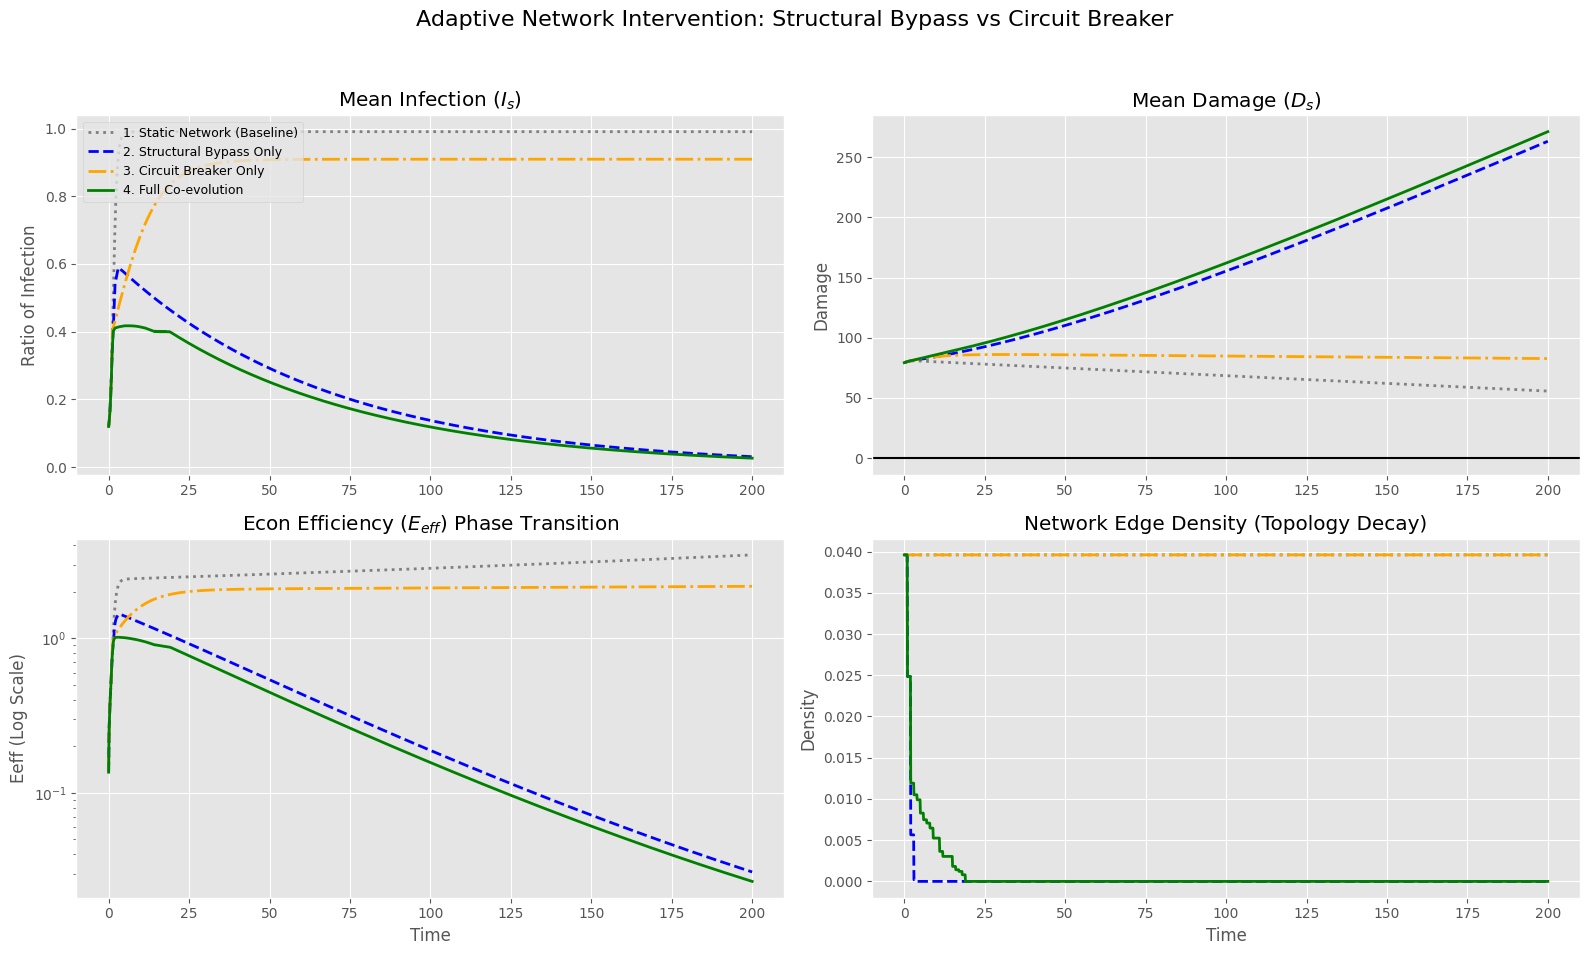


実験が完了しました。'adaptive_network_simulation_results.zip' をダウンロードします。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
import shutil
from google.colab import files

# ==========================================
# 1. ネットワークと共通パラメータの設定
# ==========================================
N = 100             # コミュニティサイズ
m = 2               # Barabasi-Albertモデルの新規エッジ数
sigma_s = 0.89      # 社会的影響力
rho = 0.74          # 非協力度
kappa = 0.52        # 攻撃係数
lam = 0.83          # ダメージ増加率
mu_base = 0.14      # 基礎ダメージ回復率
p = 0.01            # 基礎伝播係数
theta = 1.0         # 利得の歪み係数

# ==========================================
# 2. 共進化・適応的ネットワークシミュレーション関数
# ==========================================
def run_adaptive_coevolution(strategy_name, use_edge_deletion=False, use_circuit_breaker=False,
                             damage_threshold=70.0, cb_trigger_Is=0.4, cb_p_penalty=0.1):
    """
    動的エッジ切断とサーキット・ブレーカー（大域的介入）を統合したシミュレーション
    """
    # ネットワークの初期化 (各シナリオで共通の初期構造)
    G = nx.barabasi_albert_graph(N, m, seed=42)
    A = nx.to_numpy_array(G)

    dt = 0.1
    t_steps = int(200 / dt)
    time_array = np.linspace(0, 200, t_steps)

    # 状態変数の初期化
    I = np.full(N, 0.12)
    D = np.full(N, 79.28)
    E_eff = 0.01

    # スケールフリー用の伝播係数補正
    p_scale_base = p * 15.0

    records = { 'Time': [], 'Is_mean': [], 'Ds_mean': [], 'Eeff': [], 'Edge_Density': [] }

    for step, t in enumerate(time_array):

        # --------------------------------------------------
        # A. サーキット・ブレーカー（大域的・アルゴリズム的介入）
        # --------------------------------------------------
        I_mean = np.mean(I)
        p_current = p_scale_base

        # ネットワーク全体の感染度が閾値を超えた場合、伝播係数を強制減衰
        if use_circuit_breaker and I_mean > cb_trigger_Is:
            p_current = p_scale_base * cb_p_penalty

        # --------------------------------------------------
        # B. 構造的バイパス（局所的・動的エッジ切断）
        # --------------------------------------------------
        # 計算負荷軽減と物理的妥当性（人間の反応遅延）のため、一定ステップごとに評価
        if use_edge_deletion and step % 10 == 0:
            for i in range(N):
                # エージェントの局所ダメージが限界を突破した場合
                if D[i] > damage_threshold:
                    neighbors = np.where(A[i] > 0)[0]
                    if len(neighbors) > 0:
                        # 自身に繋がる最も感染度が高いノード（最大の汚染源）を特定
                        worst_neighbor = neighbors[np.argmax(I[neighbors])]

                        # 汚染源の感染度が顕著（0.5以上）であればブロック（リンク切断）
                        if I[worst_neighbor] > 0.5:
                            A[i, worst_neighbor] = 0
                            A[worst_neighbor, i] = 0

        # --------------------------------------------------
        # C. 物理演算（Euler法による連成方程式の更新）
        # --------------------------------------------------
        # 利得の歪みと複雑な伝染の乗数
        pi_t = 1.0 - (1.0 - I)**theta
        f_pi = 1.0 + 3.0 * pi_t

        # 隣接行列Aを用いた伝播演算
        neighbor_infection = A.dot(I * f_pi)
        gamma = np.full(N, 0.015) # 基礎的な抑制力

        # 微分計算
        dI_dt = p_current * (1 - I) * neighbor_infection - gamma * I
        dD_dt = lam * (1 - I) - mu_base * I + kappa * rho * (1 - I) * sigma_s

        D_mean = np.mean(D)

        # 臨界現象（相転移）のトリガー
        phase_transition_multiplier = 0.0
        if D_mean < 0 and t > 150:
            phase_transition_multiplier = 0.5 * min(-D_mean, 50.0) * E_eff

        dEeff_dt = 0.1 * (1 - E_eff) - 0.05 * max(0, D_mean) * E_eff + 10.0 * np.mean(pi_t) + phase_transition_multiplier

        # 変数の更新
        I = np.clip(I + dI_dt * dt, 0.0, 1.0)
        D = D + dD_dt * dt
        E_eff = E_eff + dEeff_dt * dt

        # データ記録
        records['Time'].append(t)
        records['Is_mean'].append(I_mean)
        records['Ds_mean'].append(D_mean)
        records['Eeff'].append(E_eff)
        records['Edge_Density'].append(np.sum(A) / (N * (N - 1))) # ネットワーク密度の推移

    return pd.DataFrame(records)

# ==========================================
# 3. 網羅的検証シナリオの実行
# ==========================================
output_dir = "adaptive_network_hypothesis"
os.makedirs(output_dir, exist_ok=True)

# 4つの象限で仮説の有効性をテスト
scenarios = {
    '1. Static Network (Baseline)': {'use_edge_deletion': False, 'use_circuit_breaker': False},
    '2. Structural Bypass Only':    {'use_edge_deletion': True,  'use_circuit_breaker': False},
    '3. Circuit Breaker Only':      {'use_edge_deletion': False, 'use_circuit_breaker': True},
    '4. Full Co-evolution':         {'use_edge_deletion': True,  'use_circuit_breaker': True}
}

results = {}
for name, params in scenarios.items():
    print(f"Running simulation: {name}...")
    df = run_adaptive_coevolution(name, **params)
    results[name] = df
    df.to_csv(os.path.join(output_dir, f"{name.replace(' ', '_')}.csv"), index=False)

# ==========================================
# 4. 力学ダイナミクスの可視化
# ==========================================
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Adaptive Network Intervention: Structural Bypass vs Circuit Breaker', fontsize=16)

colors = ['gray', 'blue', 'orange', 'green']
line_styles = [':', '--', '-.', '-']

# (1) Information State (Is)
for i, (name, df) in enumerate(results.items()):
    axes[0, 0].plot(df['Time'], df['Is_mean'], label=name, color=colors[i], linestyle=line_styles[i], linewidth=2)
axes[0, 0].set_title('Mean Infection ($I_s$)')
axes[0, 0].set_ylabel('Ratio of Infection')
axes[0, 0].legend(loc='upper left', fontsize=9)

# (2) Damage (Ds)
for i, (name, df) in enumerate(results.items()):
    axes[0, 1].plot(df['Time'], df['Ds_mean'], label=name, color=colors[i], linestyle=line_styles[i], linewidth=2)
axes[0, 1].axhline(y=0, color='black', linestyle='-')
axes[0, 1].set_title('Mean Damage ($D_s$)')
axes[0, 1].set_ylabel('Damage')

# (3) Economic Efficiency (Eeff)
for i, (name, df) in enumerate(results.items()):
    axes[1, 0].plot(df['Time'], df['Eeff'], label=name, color=colors[i], linestyle=line_styles[i], linewidth=2)
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Econ Efficiency ($E_{eff}$) Phase Transition')
axes[1, 0].set_ylabel('Eeff (Log Scale)')
axes[1, 0].set_xlabel('Time')

# (4) Edge Density (ネットワーク構造の変化)
for i, (name, df) in enumerate(results.items()):
    axes[1, 1].plot(df['Time'], df['Edge_Density'], label=name, color=colors[i], linestyle=line_styles[i], linewidth=2)
axes[1, 1].set_title('Network Edge Density (Topology Decay)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_xlabel('Time')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plot_path = os.path.join(output_dir, "adaptive_network_plots.png")
plt.savefig(plot_path, dpi=300)
plt.show()

# ==========================================
# 5. ZIP化してダウンロード
# ==========================================
zip_filename = "adaptive_network_simulation_results"
shutil.make_archive(zip_filename, 'zip', output_dir)
print(f"\n実験が完了しました。'{zip_filename}.zip' をダウンロードします。")
files.download(f"{zip_filename}.zip")